#DATA INTEGRATION

In [ ]:
import pandas as pd

xls = pd.ExcelFile('/content/partpdf_1764751473655_partpdf_1763620928546_netflix_titles.xlsx')
print(xls.sheet_names)  # See available sheet names

# Update below lines if your sheet names are different
df_titles = pd.read_excel(xls, 'netflix_titles')
df_cast = pd.read_excel(xls, 'netflix_titles_cast')
df_crew = pd.read_excel(xls, 'netflix_titles_directors') # Corrected sheet name
df_genres = pd.read_excel(xls, 'netflix_titles_category') # Changed to a plausible sheet for genres
df_countries = pd.read_excel(xls, 'netflix_titles_countries') # Added for 'country' column
# df_ratings = pd.read_excel(xls, 'netflix_titles_ratings') # This sheet appears to be missing, so it's commented out

df_master = df_titles \
    .merge(df_cast, on='show_id', how='left') \
    .merge(df_crew, on='show_id', how='left') \
    .merge(df_genres, on='show_id', how='left') \
    .merge(df_countries, on='show_id', how='left') # Merged df_countries
    #.merge(df_ratings, on='show_id', how='left') # Removed merge for missing sheet

df_master.info()

['netflix_titles', 'netflix_titles_directors', 'netflix_titles_countries', 'netflix_titles_cast', 'netflix_titles_category']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139946 entries, 0 to 139945
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   duration_minutes  98561 non-null   object 
 1   duration_seasons  41387 non-null   object 
 2   type              139945 non-null  object 
 3   title             139945 non-null  object 
 4   date_added        139785 non-null  object 
 5   release_year      139944 non-null  float64
 6   rating            139870 non-null  object 
 7   description       139943 non-null  object 
 8   show_id           139942 non-null  float64
 9   cast              138456 non-null  object 
 10  director          101031 non-null  object 
 11  listed_in         139942 non-null  object 
 12  country           134152 non-null  object 
dtypes: float64(2), object(11)
memory usage:

#Data Cleaning and Preprocessing

In [ ]:
# 1. Handle missing values - Fill missing country, director with 'Unknown'
df_master['country'] = df_master['country'].fillna('Unknown')
df_master['director'] = df_master['director'].fillna('Unknown')

# 2. Handle missing values - For date_added, leave as NaT (no fill), but convert to datetime
df_master['date_added'] = pd.to_datetime(df_master['date_added'], errors='coerce')

# 3. Create year_added column for trend analysis
df_master['year_added'] = df_master['date_added'].dt.year

# 4. (Optional) See how many missing in date_added after conversion
print(df_master['date_added'].isnull().sum())

# 5. Head and info for verification
display(df_master[['date_added','year_added','country','director']].head())
df_master.info()

162


,date_added,year_added,country,director
0,2019-09-09,2019.0,United States,Richard Finn
1,2019-09-09,2019.0,China,Richard Finn
2,2019-09-09,2019.0,India,Richard Finn
3,2019-09-09,2019.0,South Korea,Richard Finn
4,2019-09-09,2019.0,United States,Richard Finn


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139946 entries, 0 to 139945
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   duration_minutes  98561 non-null   object        
 1   duration_seasons  41387 non-null   object        
 2   type              139945 non-null  object        
 3   title             139945 non-null  object        
 4   date_added        139784 non-null  datetime64[ns]
 5   release_year      139944 non-null  float64       
 6   rating            139870 non-null  object        
 7   description       139943 non-null  object        
 8   show_id           139942 non-null  float64       
 9   cast              139946 non-null  object        
 10  director          139946 non-null  object        
 11  listed_in         139942 non-null  object        
 12  country           139946 non-null  object        
 13  year_added        139784 non-null  float64       
 14  cast

from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_1.groupby('country').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['date_added']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'date_added'}, axis=1)
              .sort_values('date_added', ascending=True))
  xs = counted['date_added']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('date_added', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('country')):
  _plot_series(series, series_name, i)
  fig.legend(title='country', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('date_added')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['year_added']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'year_added'}, axis=1)
              .sort_values('year_added', ascending=True))
  xs = counted['year_added']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('year_added', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('country')):
  _plot_series(series, series_name, i)
  fig.legend(title='country', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('year_added')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_5['index'].plot(kind='line', figsize=(8, 4), title='index')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_6['country'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_6, x='index', y='country', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

#Advanced Data Transformation

In [ ]:
# 1. Cast column la null value irundha 'Unknown' nu replace pannu (optional, safety-ku)
df_master['cast'] = df_master['cast'].fillna('Unknown')

# 2. Split the cast string by "," so each actor becomes list
df_master['cast_list'] = df_master['cast'].str.split(',')

# 3. Remove unwanted spaces (strip) for each actor
df_master['cast_list'] = df_master['cast_list'].apply(lambda x: [i.strip() for i in x])

# 4. Explode
df_exploded_cast = df_master.explode('cast_list')

# 5. Rename for clarity
df_exploded_cast = df_exploded_cast.rename(columns={'cast_list': 'actor'})

# 6. See first few rows
print(df_exploded_cast[['show_id', 'title', 'actor']].head(10))

      show_id                                    title          actor
0  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott
1  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott
2  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott
3  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott
4  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott
5  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott
6  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott
7  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott
8  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott
9  81145628.0  Norm of the North: King Sized Adventure  Alan Marriott


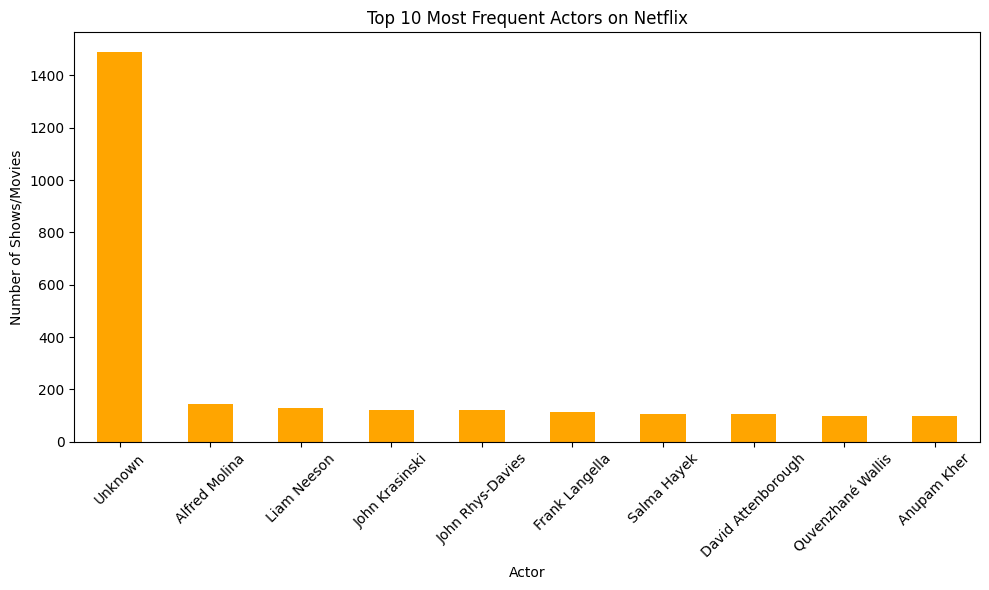

In [ ]:
import matplotlib.pyplot as plt

# 1. Top 10 most frequent actors
top_actors = df_exploded_cast['actor'].value_counts().head(10)

# 2. Bar chart plot
plt.figure(figsize=(10,6))
top_actors.plot(kind='bar', color='orange')
plt.title('Top 10 Most Frequent Actors on Netflix')
plt.ylabel('Number of Shows/Movies')
plt.xlabel('Actor')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Colab/Jupyter notebook la run pannu
df_master.to_csv('cleaned_netflix_data.csv', index=False)
# (or) If enda exploded dataframe use pandringa, `df_exploded_cast.to_csv('...')`